In [37]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras import layers, models
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

## Functions

In [38]:
def print_best_epoch(history):
    best_epoch = np.argmin(history.history['val_loss'])

    print(f"Best Epoch: {best_epoch + 1}")
    print(f"Accuracy: {history.history['accuracy'][best_epoch]:.4f}")
    print(f"Val Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
    print(f"Loss: {history.history['loss'][best_epoch]:.4f}")
    print(f"Val Loss: {history.history['val_loss'][best_epoch]:.4f}")

def plot_accuracy(history, title='Accuracy Vs Epoch'):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 1. Load CIFAR-10 Dataset

In [39]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [40]:
unique_classes = np.unique(y_train)

print(f"Classes: {unique_classes}")
print(f"Number of Classes: {len(unique_classes)}")

Classes: [0 1 2 3 4 5 6 7 8 9]
Number of Classes: 10


In [41]:
labels = y_train.flatten()

n_clas, count = np.unique(labels, return_counts=True)

print(pd.DataFrame({'Class': n_clas, 'Quantity': count}))

   Class  Quantity
0      0      5000
1      1      5000
2      2      5000
3      3      5000
4      4      5000
5      5      5000
6      6      5000
7      7      5000
8      8      5000
9      9      5000


The Dataset is balanced, each class have the same images.

In [42]:
print(f"Image Size: {X_train.shape[1:4]}") 

Image Size: (32, 32, 3)


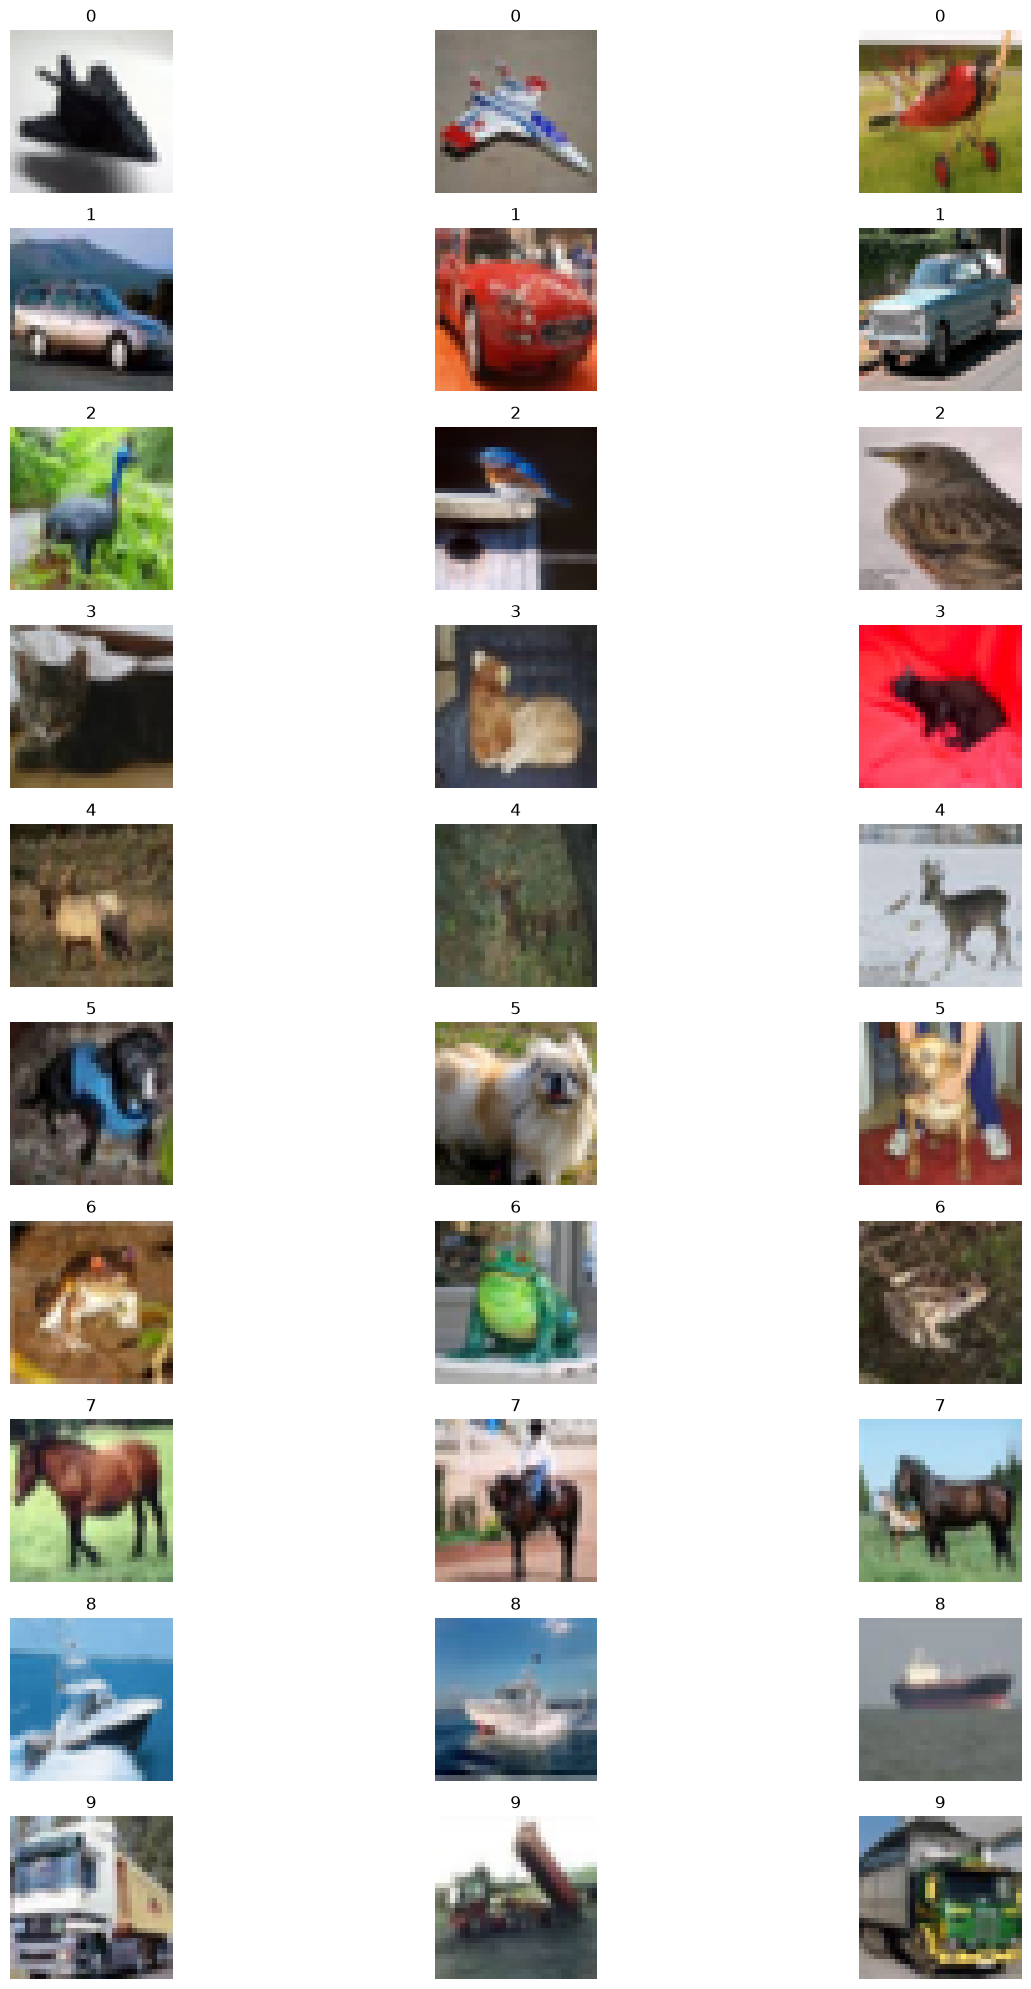

In [43]:
plt.figure(figsize=(15, 2 * len(unique_classes)))

for i, n_clase in enumerate(unique_classes):
    index = np.where(y_train.flatten() == n_clase)[0]
    
    for j in range(3):
        plt.subplot(len(unique_classes), 3, i * 3 + j + 1)
        plt.imshow(X_train[index[j]])
        plt.title(f"{n_clase}")
        plt.axis('off')
        if j == 0:
            plt.ylabel(f"{n_clase}", fontsize=12)

plt.tight_layout()
plt.show()

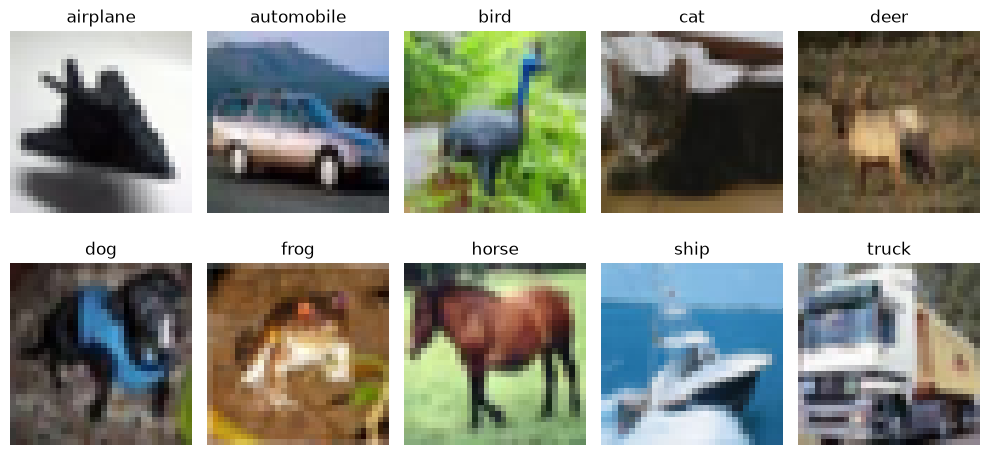

In [44]:
# Visualize some examples
class_names = ['airplane', 'automobile', 'bird', 'cat',
                'deer', 'dog' , 'frog' , 'horse', 'ship',
                'truck']

plt.figure(figsize=(10, 5))
for i in range(len(class_names)):
    idx = np.where(y_train.flatten() == i)[0][0]
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [45]:
y_train.shape

(50000, 1)

In [46]:
y_test.shape

(10000, 1)


### 2. Data Preprocessing

Before training, we need to prepare our data to fit the model:
1. **Reshape** the input images to add the channel dimension expected by CNNs.
2. **Normalize** pixel values to the [0, 1] range to speed up training.
3. **Encode** the labels using one-hot encoding for categorical classification.

We will use the `Rescaling` and `to_categorical` utilities provided by Keras.

In [47]:
# Reshape (How many values, width, height, colours channels)
X_train = X_train.reshape(-1, 32, 32, 3)
X_test = X_test.reshape(-1, 32, 32, 3)

In [48]:
# Normalization
normalization_layer = Rescaling(1./255)
X_train = normalization_layer(X_train)
X_test = normalization_layer(X_test)

In [49]:
# Convert labels to one-hot vectors
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

### 3. Build CNN model

- Optimizer: Adam

In [50]:
model = Sequential([
    # First convolutional layer with 32 filters, 3x3 kernel, ReLU activation, Input shape is 32x32 pixels with 3 colors channel (RGB)
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    # Max pooling layer to reduce spatial dimensions by a factor of 2
    MaxPooling2D(2,2),

    # Second convolutional layer with 64 filters, 3x3 kernel, ReLU activation
    Conv2D(64, (3,3), activation='relu'),
    # Another max pooling layer to reduce size further
    MaxPooling2D(2,2),

    # Flatten the 2D feature maps into a 1D vector for dense layers
    Flatten(),
    
    # Fully connected (dense) layer with 128 neurons and ReLU activation
    #Learns intermediate features from the previous layers
    Dense(128, activation='relu'),
    # Output layer with 10 neurons (for 10 classes) and softmax activation
    #Produces the final probabilities for each class.
    Dense(10, activation='softmax')
])

model.summary()

c:\Users\alber\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# EarlyStopping is going to be used to prevent overfitting by stopping the training proces when val_loss stop improving.
# After 8 epochs, trainning will stop.
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history=model.fit(X_train, y_train_cat, epochs=100, validation_split=0.2, callbacks=[early_stop])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4669 - loss: 1.4794 - val_accuracy: 0.5621 - val_loss: 1.2375
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6062 - loss: 1.1232 - val_accuracy: 0.6273 - val_loss: 1.0732
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6609 - loss: 0.9742 - val_accuracy: 0.6602 - val_loss: 0.9792
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6953 - loss: 0.8711 - val_accuracy: 0.6738 - val_loss: 0.9500
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7258 - loss: 0.7798 - val_accuracy: 0.6918 - val_loss: 0.9064
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7534 - loss: 0.7098 - val_accuracy: 0.6911 - val_loss: 0.9077
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7779 - loss: 0.6348 - val_accuracy: 0.6815 - val_loss: 0.9684
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7983 - loss: 0

In [52]:
print_best_epoch(history)

Best Epoch: 5
Accuracy: 0.7258
Val Accuracy: 0.6918
Loss: 0.7798
Val Loss: 0.9064


In [53]:
# The result shows that the dataset is overfitting: Accuracy is higher than val accuracy.
# val_accuracy is lower than accuracy and stop improving after epoch 6.
# No more improvement after epoch 6, early stop has triggered.

In [54]:
# Rebuild the CNN model adding a new layer and a Dropout (0.30) after the first dense layer.

model_v2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.30),
    
    Dense(10, activation='softmax'),
])

model_v2.summary()

model_v2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_v2=model_v2.fit(X_train, y_train_cat, epochs=100, validation_split=0.2, callbacks=[early_stop])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4032 - loss: 1.6230 - val_accuracy: 0.5373 - val_loss: 1.2899
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5578 - loss: 1.2412 - val_accuracy: 0.6046 - val_loss: 1.1084
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6182 - loss: 1.0801 - val_accuracy: 0.6483 - val_loss: 0.9963
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6609 - loss: 0.9633 - val_accuracy: 0.6539 - val_loss: 1.0068
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6921 - loss: 0.8750 - val_accuracy: 0.6806 - val_loss: 0.9192
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7197 - loss: 0.8075 - val_accuracy: 0.6942 - val_loss: 0.8882
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7388 - loss: 0.7470 - val_accuracy: 0.6923 - val_loss: 0.8972
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7560 - loss: 0

In [55]:
print_best_epoch(history_v2)

Best Epoch: 10
Accuracy: 0.7903
Val Accuracy: 0.7246
Loss: 0.6006
Val Loss: 0.8265


In [56]:
# Rebuild the CNN model adding a new layer and a Dropout (0.30) after the first dense layer helps to improve the val_accuracy and val_loss.
# Val_accuracy is still lower than accuracy, model is still overfitting, but the results are better adding a layer and dropout.
# Seems like adding dropout the gap between Accuracy and Val_Accuracy is lower.

In [57]:
# Rebuild the CNN model adding a Dropout (0.05) after the first convolutional layer.

model_v3 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Dropout(0.05),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(10, activation='softmax'),
])

model_v3.summary()

model_v3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_v3=model_v3.fit(X_train, y_train_cat, epochs=100, validation_split=0.2, callbacks=[early_stop])

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3765 - loss: 1.6798 - val_accuracy: 0.4969 - val_loss: 1.4012
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5347 - loss: 1.3030 - val_accuracy: 0.5952 - val_loss: 1.1596
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5915 - loss: 1.1481 - val_accuracy: 0.6331 - val_loss: 1.0501
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6348 - loss: 1.0365 - val_accuracy: 0.6292 - val_loss: 1.0426
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6604 - loss: 0.9627 - val_accuracy: 0.6762 - val_loss: 0.9265
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6832 - loss: 0.8969 - val_accuracy: 0.6820 - val_loss: 0.9127
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7038 - loss: 0.8457 - val_accuracy: 0.6984 - val_loss: 0.8782
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7197 - loss: 0

In [58]:
print_best_epoch(history_v3)

Best Epoch: 11
Accuracy: 0.7561
Val Accuracy: 0.7133
Loss: 0.6875
Val Loss: 0.8438


In [59]:
# Adding dropout in the configuration layer from the first part of our CNN, the gap decrease but Val_Accuracy decrease too.

In [72]:
# Rebuild the CNN model adding a Dropout (0.10) after the second convolutional layer.

model_v4 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Dropout(0.05),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

     Dropout(0.10),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(10, activation='softmax'),
])

model_v4.summary()

model_v4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_v4=model_v4.fit(X_train, y_train_cat, epochs=100, validation_split=0.2, callbacks=[early_stop])

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_37 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3878 - loss: 1.6588 - val_accuracy: 0.5239 - val_loss: 1.3272
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5330 - loss: 1.3051 - val_accuracy: 0.5916 - val_loss: 1.1714
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5906 - loss: 1.1631 - val_accuracy: 0.6314 - val_loss: 1.0545
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6296 - loss: 1.0540 - val_accuracy: 0.6496 - val_loss: 1.0004
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6577 - loss: 0.9727 - val_accuracy: 0.6801 - val_loss: 0.9280
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6784 - loss: 0.9159 - val_accuracy: 0.6918 - val_loss: 0.8885
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6981 - loss: 0.8626 - val_accuracy: 0.6907 - val_loss: 0.8865
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7123 - loss: 0

In [73]:
print_best_epoch(history_v4)

Best Epoch: 12
Accuracy: 0.7573
Val Accuracy: 0.7253
Loss: 0.6969
Val Loss: 0.8139


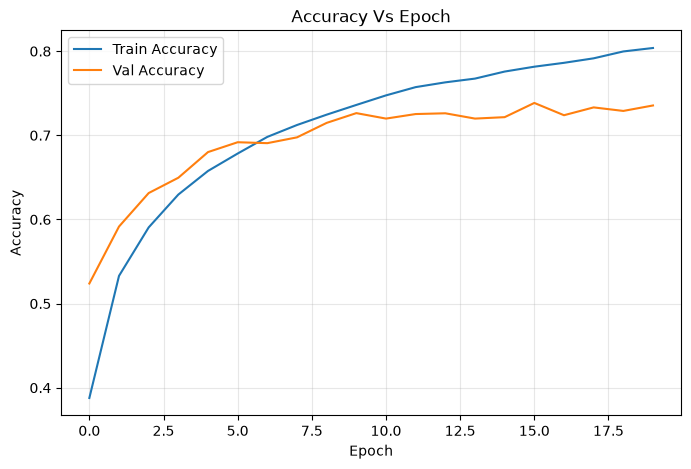

In [74]:
plot_accuracy(history_v4)

In [75]:
# Adding a new dropout in the Convolutional Layers has improved the results but the gap is more or less the same as before.

In [76]:
# Trying to improve the results, LEarning Rate will be decreased.
# The result expected is the gap will be higher as before but Val_accuracy it could be higher too.

model_v4_lr0001 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Dropout(0.05),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

     Dropout(0.10),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(10, activation='softmax'),
])

model_v4_lr0001.summary()


model_v4_lr0001.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_v4_lr0001=model_v4_lr0001.fit(X_train, y_train_cat, epochs=100, validation_split=0.2, callbacks=[early_stop])

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2695 - loss: 1.9631 - val_accuracy: 0.3812 - val_loss: 1.7111
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3907 - loss: 1.6598 - val_accuracy: 0.4400 - val_loss: 1.5476
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4407 - loss: 1.5328 - val_accuracy: 0.4782 - val_loss: 1.4484
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4723 - loss: 1.4569 - val_accuracy: 0.5044 - val_loss: 1.3839
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4929 - loss: 1.4001 - val_accuracy: 0.5358 - val_loss: 1.3165
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5160 - loss: 1.3482 - val_accuracy: 0.5501 - val_loss: 1.2869
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5334 - loss: 1.3029 - val_accuracy: 0.5578 - val_loss: 1.2627
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5454 - loss: 1

In [77]:
print_best_epoch(history_v4_lr0001)

Best Epoch: 57
Accuracy: 0.8012
Val Accuracy: 0.7408
Loss: 0.5653
Val Loss: 0.7655


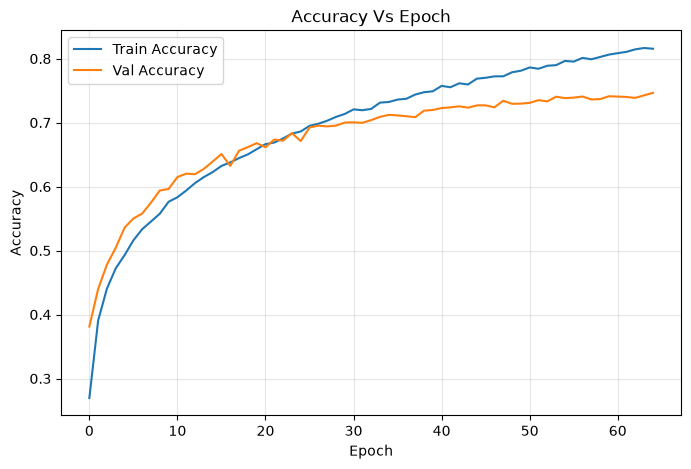

In [78]:
plot_accuracy(history_v4_lr0001)

In [79]:
# Decreasing Learning Rate on Adam Optimizer, model takes much more time then the model memorize better, because It's needed more epochs but the results are better.

- Optimizer: SDG

In [80]:
# This time we will use SDG optimizer instead of Adam.
# We are going to use same configuration of model_v4 because it has a better val_accuracy (0.76). 

model_v4_sdg = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Dropout(0.05),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Dropout(0.10),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(10, activation='softmax'),
])

model_v4_sdg.summary()

sgd = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

model_v4_sdg.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_v4_sdg=model_v4_sdg.fit(X_train, y_train_cat, epochs=100, validation_split=0.2, callbacks=[early_stop])


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_43 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3221 - loss: 1.8342 - val_accuracy: 0.4483 - val_loss: 1.5271
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4834 - loss: 1.4287 - val_accuracy: 0.5497 - val_loss: 1.2759
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5521 - loss: 1.2583 - val_accuracy: 0.5819 - val_loss: 1.1888
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5927 - loss: 1.1482 - val_accuracy: 0.6355 - val_loss: 1.0546
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6276 - loss: 1.0626 - val_accuracy: 0.6546 - val_loss: 0.9903
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6544 - loss: 0.9918 - val_accuracy: 0.6632 - val_loss: 0.9587
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6707 - loss: 0.9399 - val_accuracy: 0.6641 - val_loss: 0.9641
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6904 - loss: 0

In [81]:
print_best_epoch(history_v4_sdg)

Best Epoch: 13
Accuracy: 0.7383
Val Accuracy: 0.7072
Loss: 0.7450
Val Loss: 0.8669


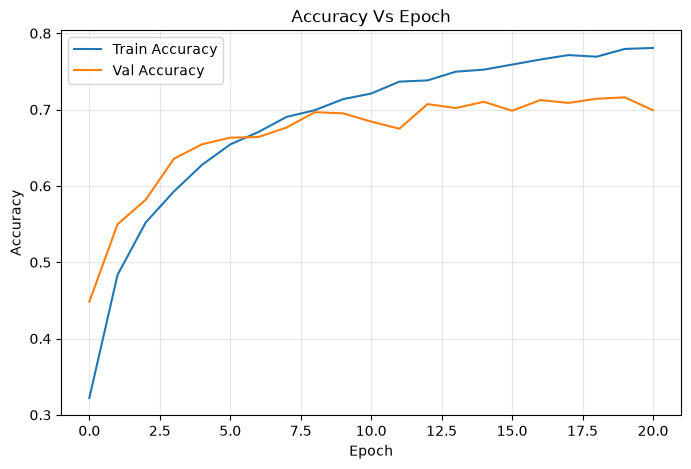

In [82]:
plot_accuracy(history_v4_sdg)

In [83]:
# SDG doesnt improve the val_accuracy and val_loss as much as Adam optimizer.

In [84]:
model_v4_sdg_lr001 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Dropout(0.05),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Dropout(0.10),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(10, activation='softmax'),
])

model_v4_sdg_lr001.summary()

sgd = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

model_v4_sdg_lr001.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_v4_sdg_lr001=model_v4_sdg_lr001.fit(X_train, y_train_cat, epochs=100, validation_split=0.2, callbacks=[early_stop])

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2021 - loss: 2.1290 - val_accuracy: 0.2757 - val_loss: 1.9657
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3151 - loss: 1.8515 - val_accuracy: 0.3821 - val_loss: 1.7146
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3720 - loss: 1.7050 - val_accuracy: 0.4234 - val_loss: 1.5915
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4117 - loss: 1.6093 - val_accuracy: 0.4444 - val_loss: 1.5297
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4467 - loss: 1.5259 - val_accuracy: 0.4849 - val_loss: 1.4410
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4712 - loss: 1.4606 - val_accuracy: 0.5033 - val_loss: 1.3900
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4964 - loss: 1.4004 - val_accuracy: 0.5316 - val_loss: 1.3375
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5139 - loss: 1

In [85]:
print_best_epoch(history_v4_sdg_lr001)

Best Epoch: 46
Accuracy: 0.7918
Val Accuracy: 0.7448
Loss: 0.5908
Val Loss: 0.7610


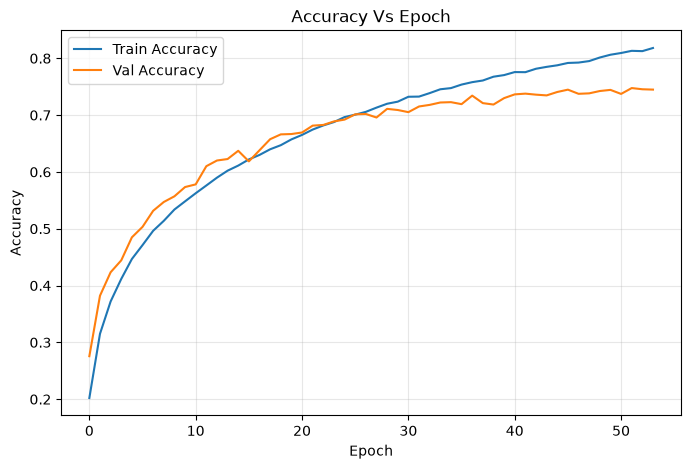

In [86]:
plot_accuracy(history_v4_sdg_lr001)

In [87]:
# The result decreasing Learning Rate in SDG is the same as Adam. Val_Accuracy is better but models goes to Overfitting because the gap becomes greater.

# Data augmentation

In [88]:
# We are going to try with another methods to improve our results taking Movel_v4_lr [ADAM] as It's the one with best results.

In [141]:
# Take the original dataset for the data augmentation
(X_train_da, y_train_da), _ = cifar10.load_data()


X_train_da = X_train_da.astype('float32') / 255.0

split_idx = int(len(X_train_da) * 0.8)
X_tr, X_val = X_train_da[:split_idx], X_train_da[split_idx:]
y_tr, y_val = y_train_cat[:split_idx], y_train_cat[split_idx:]

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.01,
    height_shift_range=0.01,
    zoom_range=0.05,
    horizontal_flip=True
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_datag=model_v4_lr0001.fit(datagen.flow(X_tr, y_tr, batch_size=64), epochs=100, validation_data=(X_val, y_val), callbacks=[early_stop])

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7544 - loss: 0.7068 - val_accuracy: 0.7714 - val_loss: 0.6660
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7567 - loss: 0.7054 - val_accuracy: 0.7793 - val_loss: 0.6502
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7592 - loss: 0.6942 - val_accuracy: 0.7695 - val_loss: 0.6690
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7599 - loss: 0.6908 - val_accuracy: 0.7673 - val_loss: 0.6747
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.7629 - loss: 0.6827 - val_accuracy: 0.7708 - val_loss: 0.6680
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7633 - loss: 0.6838 - val_accuracy: 0.7606 - val_loss: 0.6942
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7617 - loss: 0.6809 - val_accuracy: 0.7742 - val_loss: 0.6625
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7648 - loss: 0

In [142]:
print_best_epoch(history_datag)

Best Epoch: 2
Accuracy: 0.7567
Val Accuracy: 0.7793
Loss: 0.7054
Val Loss: 0.6502


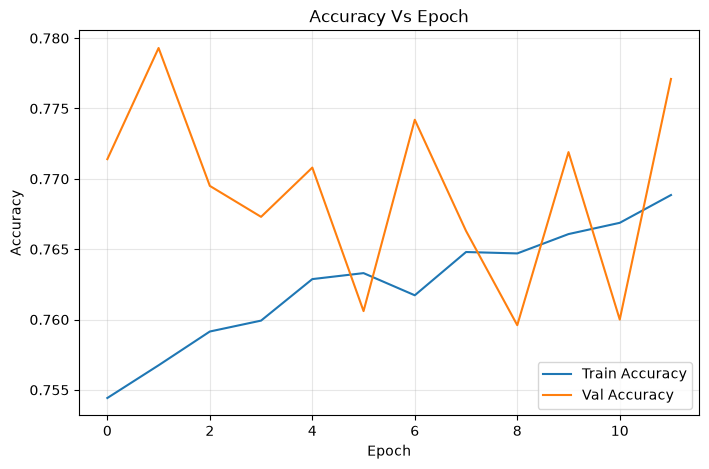

In [143]:
plot_accuracy(history_datag)

In [144]:
# We will test Data augmentation with the model fitted with SDG 

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_datag_sdg=model_v4_sdg_lr001.fit(datagen.flow(X_tr, y_tr, batch_size=64), epochs=100, validation_data=(X_val, y_val), callbacks=[early_stop])

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7359 - loss: 0.7644 - val_accuracy: 0.7504 - val_loss: 0.7368
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7358 - loss: 0.7581 - val_accuracy: 0.7409 - val_loss: 0.7609
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7383 - loss: 0.7495 - val_accuracy: 0.7388 - val_loss: 0.7692
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7394 - loss: 0.7498 - val_accuracy: 0.7353 - val_loss: 0.7875
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7404 - loss: 0.7455 - val_accuracy: 0.7415 - val_loss: 0.7695
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7429 - loss: 0.7360 - val_accuracy: 0.7472 - val_loss: 0.7533
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7428 - loss: 0.7321 - val_accuracy: 0.7380 - val_loss: 0.7742
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7497 - loss: 0

In [145]:
print_best_epoch(history_datag_sdg)

Best Epoch: 9
Accuracy: 0.7479
Val Accuracy: 0.7611
Loss: 0.7218
Val Loss: 0.7027


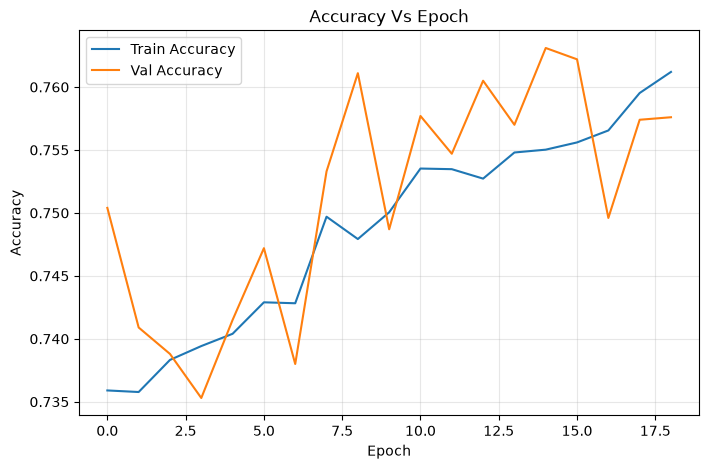

In [146]:
plot_accuracy(history_datag_sdg)

In [147]:
# Predict class probabilities

y_pred_probs = model_v4_lr0001.predict(X_test)

# Convert probabilities to class predictions
y_pred_v4_adam = y_pred_probs.argmax(axis=1)
y_true_v4_adam = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true_v4_adam, y_pred_v4_adam)
prec = precision_score(y_true_v4_adam, y_pred_v4_adam, average='weighted')
rec = recall_score(y_true_v4_adam, y_pred_v4_adam, average='weighted')
f1 = f1_score(y_true_v4_adam, y_pred_v4_adam, average='weighted')

print(f"Accuracy [ADAM]: {acc:.4f}")
print(f"Precision [ADAM]: {prec:.4f}")
print(f"Recall [ADAM]: {rec:.4f}")
print(f"F1 Score [ADAM]: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy [ADAM]: 0.7507
Precision [ADAM]: 0.7498
Recall [ADAM]: 0.7507
F1 Score [ADAM]: 0.7459


In [148]:
# Predict class probabilities
y_pred_probs = model_v4_sdg_lr001.predict(X_test)

# Convert probabilities to class predictions
y_pred_v4_sdg = y_pred_probs.argmax(axis=1)
y_true_v4_sdg = y_test  # original integer labels

# Compute metrics
acc_sdg = accuracy_score(y_true_v4_sdg, y_pred_v4_sdg)
prec_sdg = precision_score(y_true_v4_sdg, y_pred_v4_sdg, average='weighted')
rec_sdg = recall_score(y_true_v4_sdg, y_pred_v4_sdg, average='weighted')
f1_sdg = f1_score(y_true_v4_sdg, y_pred_v4_sdg, average='weighted')

print(f"Accuracy [SDG]: {acc_sdg:.4f}")
print(f"Precision [SDG]: {prec_sdg:.4f}")
print(f"Recall [SDG]: {rec_sdg:.4f}")
print(f"F1 Score [SDG]: {f1_sdg:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy [SDG]: 0.7498
Precision [SDG]: 0.7505
Recall [SDG]: 0.7498
F1 Score [SDG]: 0.7465


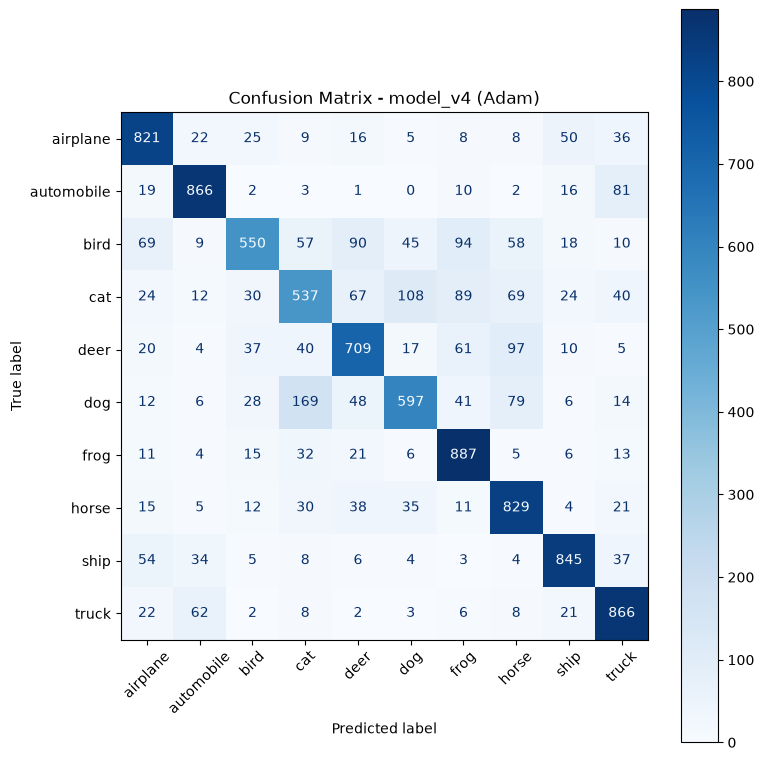

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true_v4_adam, y_pred_v4_adam)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)
plt.title('Confusion Matrix - model_v4 (Adam)')
plt.tight_layout()
plt.show()

In [100]:
# The model use to predict correctly but there are some confusiions between classes.
# The model has a big confusion between classes Cat and Dog.
# Bird class has confusion with Cat, Deer and Dog.

### 5. Transfer Learning with MobileNetV2

MobileNetV2 will be used in ImageNet.
Images have to be resized from 32x32 to 128x128 because MobileNet has been trained in this resolution.

In [101]:
# Load dataset
(X_train_tf, y_train_tf), (X_test_tf, y_test_tf) = cifar10.load_data()

In [102]:
# First part of the project X_train/X_Test were Rescaling, but as MobileNet will be used, we can keep the original scale from CIFAR,
# Because MobileNetV2 expects pixel values in the range [0,255].

X_train_tf = tf.image.resize(X_train_tf, (128, 128))
X_test_tf = tf.image.resize(X_test_tf, (128, 128))

X_train_tf = preprocess_input(X_train_tf.numpy())
X_test_tf = preprocess_input(X_test_tf.numpy())


In [103]:
# Build transfer learning model
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

In [104]:
model_tl = models.Sequential([
    base_model,
    GlobalAveragePooling2D(), 

    #Same Config as the last CNN model
    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(10, activation='softmax'),
])

model_tl.summary()


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [105]:
model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_tl = model_tl.fit(X_train_tf, y_train_cat, epochs=100, validation_split=0.2, batch_size=64, callbacks=[early_stop_tl])


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 351ms/step - accuracy: 0.7851 - loss: 0.6351 - val_accuracy: 0.8429 - val_loss: 0.4400
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 318ms/step - accuracy: 0.8442 - loss: 0.4543 - val_accuracy: 0.8540 - val_loss: 0.4160
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 308ms/step - accuracy: 0.8599 - loss: 0.4053 - val_accuracy: 0.8625 - val_loss: 0.3920
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 308ms/step - accuracy: 0.8719 - loss: 0.3693 - val_accuracy: 0.8606 - val_loss: 0.3967
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 311ms/step - accuracy: 0.8781 - loss: 0.3457 - val_accuracy: 0.8663 - val_loss: 0.3867
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.8851 - loss: 0.3270 - val_accuracy: 0.8647 - val_loss: 0.4000
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 308ms/step - accuracy: 0.8922 - loss: 0.3049 - val_accuracy: 0.8631 - val_loss: 0.3979
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 310ms/step - accuracy: 

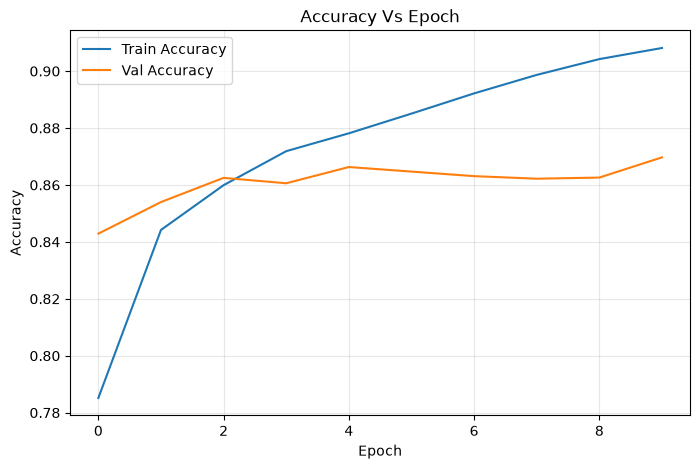

In [106]:
plot_accuracy(history_tl)

In [107]:
print_best_epoch(history_tl)

Best Epoch: 5
Accuracy: 0.8781
Val Accuracy: 0.8663
Loss: 0.3457
Val Loss: 0.3867


In [108]:
# Learning Rate 0.0001 as the best config with our own CNN
model_tl_lr0001 = models.Sequential([
    base_model,
    GlobalAveragePooling2D(), 

    #Same Config as the last CNN model
    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(10, activation='softmax'),
])

model_tl_lr0001.summary()


model_tl_lr0001.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_tl_lr = model_tl_lr0001.fit(X_train_tf, y_train_cat, epochs=100, validation_split=0.2, batch_size=64, callbacks=[early_stop_tl])

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 197s 311ms/step - accuracy: 0.6547 - loss: 1.0368 - val_accuracy: 0.8107 - val_loss: 0.5578
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 310ms/step - accuracy: 0.7962 - loss: 0.6032 - val_accuracy: 0.8342 - val_loss: 0.4791
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 312ms/step - accuracy: 0.8249 - loss: 0.5191 - val_accuracy: 0.8432 - val_loss: 0.4473
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 312ms/step - accuracy: 0.8372 - loss: 0.4778 - val_accuracy: 0.8502 - val_loss: 0.4274
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 307ms/step - accuracy: 0.8487 - loss: 0.4424 - val_accuracy: 0.8548 - val_loss: 0.4144
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 312ms/step - accuracy: 0.8561 - loss: 0.4181 - val_accuracy: 0.8547 - val_loss: 0.4064
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 313ms/step - accuracy: 0.8636 - loss: 0.3979 - val_accuracy: 0.8593 - val_loss: 0.3990
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 197s 315ms/step - accuracy: 

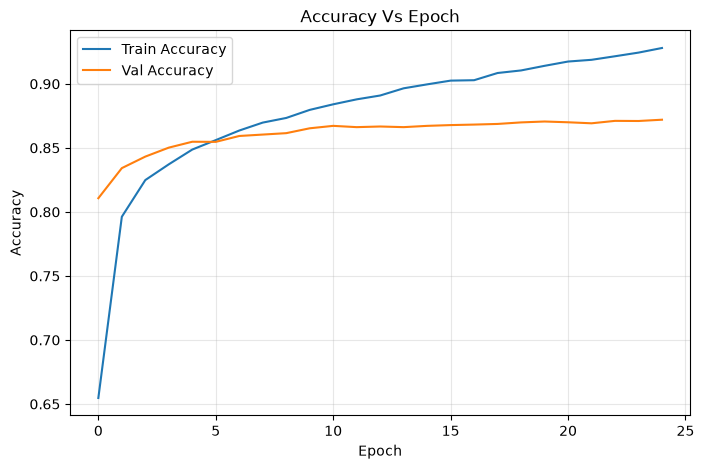

In [109]:
plot_accuracy(history_tl_lr)

In [110]:
print_best_epoch(history_tl_lr)

Best Epoch: 20
Accuracy: 0.9141
Val Accuracy: 0.8706
Loss: 0.2522
Val Loss: 0.3684


## Fine Tuning

In [120]:
# To get more out of the model, Fine Tunning will be done.
# The objective is to see how  affect to the results regarding of how many layers are unfreeze.

In [121]:
# Same config as the best model that we get until now, but unfreezing 10 layers.

base_model_10 = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
base_model_10.trainable = False

model_tl_10 = models.Sequential([
    base_model_10, 
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'), 
    Dropout(0.30),
    Dense(10, activation='softmax'),
])
model_tl_10.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_head_10 = model_tl_10.fit(X_train_tf, y_train_cat, epochs=100, validation_split=0.2, batch_size=64, callbacks=[early_stop])

# Unfreeze 10 layers
base_model_10.trainable = True
for layer in base_model_10.layers[:-10]:
    layer.trainable = False

model_tl_10.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_ft_10 = model_tl_10.fit(X_train_tf, y_train_cat, epochs=30, validation_split=0.2, batch_size=64, callbacks=[early_stop_ft])

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 180s 279ms/step - accuracy: 0.6517 - loss: 1.0360 - val_accuracy: 0.8108 - val_loss: 0.5577
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 183s 293ms/step - accuracy: 0.7967 - loss: 0.5992 - val_accuracy: 0.8333 - val_loss: 0.4814
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 294ms/step - accuracy: 0.8233 - loss: 0.5198 - val_accuracy: 0.8437 - val_loss: 0.4473
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 183s 293ms/step - accuracy: 0.8387 - loss: 0.4769 - val_accuracy: 0.8512 - val_loss: 0.4267
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 178s 285ms/step - accuracy: 0.8501 - loss: 0.4404 - val_accuracy: 0.8518 - val_loss: 0.4155
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 179s 286ms/step - accuracy: 0.8564 - loss: 0.4199 - val_accuracy: 0.8563 - val_loss: 0.4047
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 283ms/step - accuracy: 0.8629 - loss: 0.3976 - val_accuracy: 0.8586 - val_loss: 0.3984
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 180s 288ms/step - accuracy: 

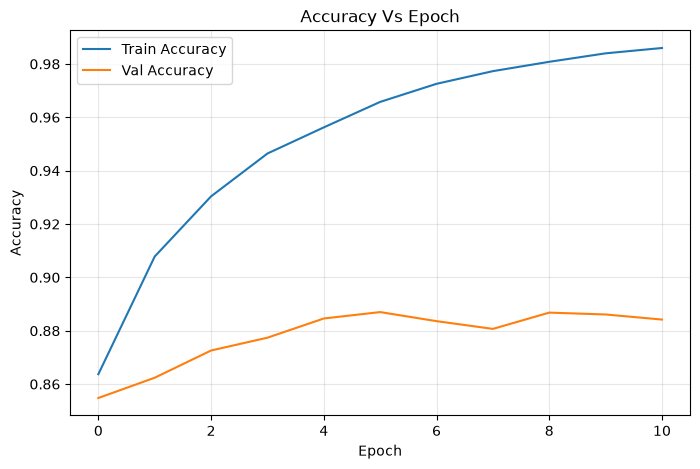

In [122]:
plot_accuracy(history_ft_10)

In [124]:
print_best_epoch(history_ft_10)

Best Epoch: 6
Accuracy: 0.9658
Val Accuracy: 0.8870
Loss: 0.1014
Val Loss: 0.3850


In [132]:
# Same config as the best model that we get until now, but unfreezing 20 layers.

base_model_20 = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
base_model_20.trainable = False

model_tl_20 = models.Sequential([
    base_model_20, 
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'), 
    Dropout(0.30),
    Dense(10, activation='softmax'),
])
model_tl_20.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_head_20 = model_tl_20.fit(X_train_tf, y_train_cat, epochs=100, validation_split=0.2, batch_size=64, callbacks=[early_stop])

# Unfreeze 20 layers
base_model_20.trainable = True
for layer in base_model_20.layers[:-20]:
    layer.trainable = False

model_tl_20.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_ft_20 = model_tl_20.fit(X_train_tf, y_train_cat, epochs=30, validation_split=0.2, batch_size=64, callbacks=[early_stop_ft])


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 305ms/step - accuracy: 0.6414 - loss: 1.0814 - val_accuracy: 0.8107 - val_loss: 0.5646
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 198s 317ms/step - accuracy: 0.7955 - loss: 0.6066 - val_accuracy: 0.8357 - val_loss: 0.4853
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 321ms/step - accuracy: 0.8221 - loss: 0.5206 - val_accuracy: 0.8434 - val_loss: 0.4509
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 321ms/step - accuracy: 0.8389 - loss: 0.4750 - val_accuracy: 0.8500 - val_loss: 0.4321
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 198s 318ms/step - accuracy: 0.8474 - loss: 0.4447 - val_accuracy: 0.8552 - val_loss: 0.4162
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 200s 319ms/step - accuracy: 0.8572 - loss: 0.4206 - val_accuracy: 0.8573 - val_loss: 0.4072
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 200s 320ms/step - accuracy: 0.8640 - loss: 0.3960 - val_accuracy: 0.8573 - val_loss: 0.4022
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 198s 317ms/step - accuracy: 

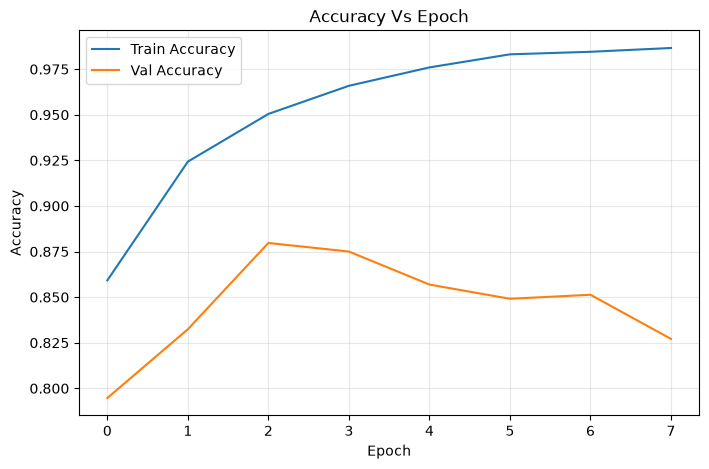

In [133]:
plot_accuracy(history_ft_20)

In [134]:
print_best_epoch(history_ft_20)

Best Epoch: 3
Accuracy: 0.9505
Val Accuracy: 0.8797
Loss: 0.1451
Val Loss: 0.4194


## Evaluation of the model for transfer learning

In [138]:
# Predict class probabilities
y_pred_probs_tl = model_tl_10.predict(X_test_tf)  

# Convert probabilities to class predictions
y_pred_tl = y_pred_probs_tl.argmax(axis=1)
y_true_tl = y_test  # original integer labels

# Compute metrics
acc_tl = accuracy_score(y_true_tl, y_pred_tl)
prec_tl = precision_score(y_true_tl, y_pred_tl, average='weighted')
rec_tl = recall_score(y_true_tl, y_pred_tl, average='weighted')
f1_tl = f1_score(y_true_tl, y_pred_tl, average='weighted')

print(f"Accuracy [MobileNetV2]: {acc_tl:.4f}")
print(f"Precision [MobileNetV2]: {prec_tl:.4f}")
print(f"Recall [MobileNetV2]: {rec_tl:.4f}")
print(f"F1 Score [MobileNetV2]: {f1_tl:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 103ms/step
Accuracy [MobileNetV2]: 0.8839
Precision [MobileNetV2]: 0.8850
Recall [MobileNetV2]: 0.8839
F1 Score [MobileNetV2]: 0.8840


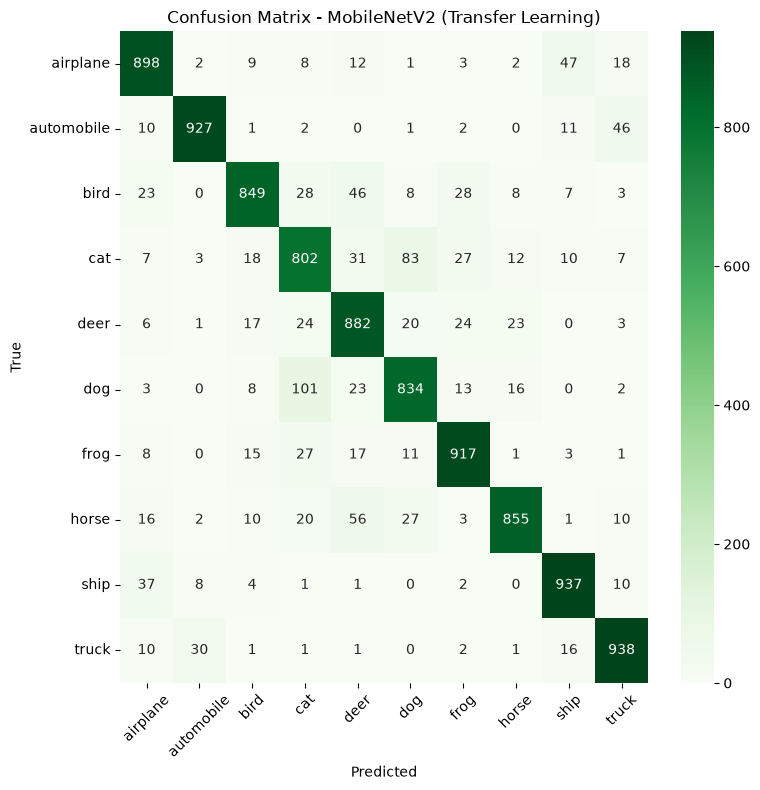

In [139]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV2 (Transfer Learning)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 6. OWN CNN Vs Transfer Learning

In [150]:
comparison_df = pd.DataFrame({
    'Model': ['Own CNN + DA (model_v4, Adam)', 'MobileNetV2 (TL)'],
    'Accuracy': [acc, acc_tl],
    'Precision': [prec, prec_tl],
    'Recall': [rec, rec_tl],
    'F1-Score': [f1, f1_tl]
})
print(comparison_df)




                           Model  Accuracy  Precision  Recall  F1-Score
0  Own CNN + DA (model_v4, Adam)    0.7507   0.749848  0.7507  0.745950
1               MobileNetV2 (TL)    0.8839   0.884961  0.8839  0.883965
